# Questão 1: Agrupamento de perfis municipais de saúde com K-Means

In [1]:
import pandas as pd


indicadores = ['sim_3_1', 'sim_3_3', 'sim_3_4', 'sih_3_1', 'sih_3_2']

df = (
    pd.read_parquet('../data.parquet')
    .query('id_indicator in @indicadores').reset_index(drop=True)
    .pivot(index="id_local", columns="id_indicator", values="value")
)
df.head()

id_indicator,sih_3_1,sih_3_2,sim_3_1,sim_3_3,sim_3_4
id_local,,,,,
2500106,0.0,0.0,0.0000,0.0,225.9691
2500205,NaN,NaN,12.8205,0.0,91.4077
2500304,0.0,0.0,7.1225,0.0,211.9318
2500403,0.0,0.0,3.4602,0.0,169.9235
2500502,NaN,NaN,66.6667,0.0,114.0143


### a) Determine o número de clusters k. Apresente o método do e o coeficiente de silhueta para k variando de 2 a 10. Mostre os gráficos correspondentes e justifique a escolha do k.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

X_scaled = preprocess.fit_transform(df[indicadores].copy())

inertia = []
silhouette = []
for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    
    inertia.append(km.inertia_)
    
    labels = km.predict(X_scaled)
    silhouette.append(silhouette_score(X_scaled, labels))

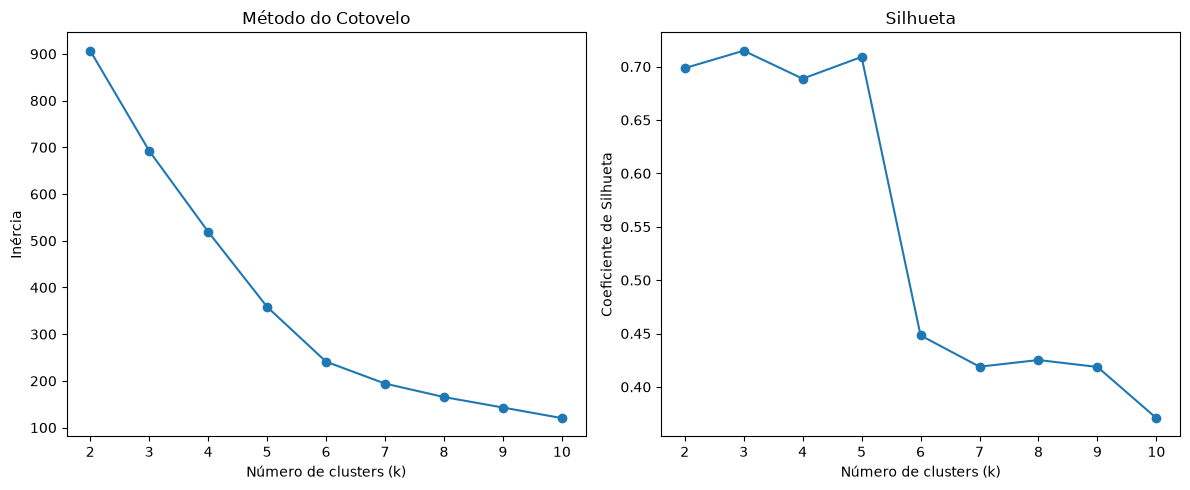

In [3]:
import matplotlib.pyplot as plt

ks = range(2, 11)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ks, inertia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")

plt.subplot(1,2,2)
plt.plot(ks, silhouette, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhueta")
plt.title("Silhueta")

plt.tight_layout()
plt.show()

O método do cotovelo consiste em analisar a redução da inércia à medida que o número de clusters aumenta. Observou-se que a curva apresenta uma mudança mais evidente de inclinação em (k = 6), caracterizando o "cotovelo". A partir desse ponto, o acréscimo de novos clusters proporciona apenas pequenas reduções na inércia, indicando retornos decrescentes em relação à melhoria do agrupamento.

Por outro lado, o coeficiente de silhueta avalia simultaneamente a coesão interna dos clusters e a separação entre eles. O maior valor foi obtido para k = 3 (aproximadamente 0,715), indicando que essa configuração produz grupos bem definidos e altamente separados entre si. O valor de k = 5 também apresentou desempenho muito próximo (cerca de 0,710), enquanto, a partir de k = 6, houve uma redução acentuada da silhueta para valores inferiores a 0,45, evidenciando perda significativa na qualidade dos agrupamentos.

Por esse motivo, apresentando o melhor equilíbrio entre ambos os métodos, o K escolhido foi o de ordem 5.

### b) Ajuste o K-Means com o k escolhido e adicione ao DataFrame uma coluna com o rótulo do cluster de cada município. Caracterize cada cluster pela média de cada indicador e proponha um rótulo interpretativo para cada grupo (por exemplo, “municípios com alta mortalidade materno-infantil”). Preencha a tabela abaixo.

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_cluster = df.copy()
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

perfil_clusters = (
    df_cluster
    .groupby("cluster")[indicadores]
    .mean()
    .round(2)
)

perfil_clusters["Nº mun."] = df_cluster.groupby("cluster").size()
perfil_clusters

id_indicator,sim_3_1,sim_3_3,sim_3_4,sih_3_1,sih_3_2,Nº mun.
cluster,,,,,,
0,8.57,1.40,163.61,15.13,2.24,207
1,10.57,752.35,180.69,7.65,0.00,6
2,5.61,6.66,210.72,260.42,72.36,10


| Cluster | Rótulo                                                                     |
| ------- | -------------------------------------------------------------------------- |
| **0**   | Municípios com perfil de saúde intermediário e menor vulnerabilidade geral |
| **1**   | Municípios com elevada mortalidade materna e infantil                      |
| **2**   | Municípios com alta carga de doenças crônicas e internações por arboviroses, álcool e drogas.      |


### c) Identifique, para cada cluster, os três municípios mais representativos (os mais próximos do centróide do seu grupo) e comente se o agrupamento faz sentido do ponto de vista epidemiológico.

In [10]:
from scipy.spatial.distance import cdist

distancias = cdist(
    X_scaled,
    kmeans.cluster_centers_,
    metric="euclidean"
)

df_cluster["distancia_centroide"] = [
    distancias[i, cluster]
    for i, cluster in enumerate(df_cluster["cluster"])
]

representativos = (
    df_cluster
    .reset_index()
    .sort_values("distancia_centroide")
    .groupby("cluster")
    .head(3)
)

representativos[[
    "cluster",
    "id_local",
    "distancia_centroide"
]]

id_indicator,cluster,id_local,distancia_centroide
55,0,2504157,0.042136
75,0,2505600,0.111674
122,0,2509602,0.112580
27,1,2502003,0.389214
195,1,2515005,1.077185
83,1,2506301,1.203755
213,2,2516508,1.461122
214,2,2516607,1.542596
123,2,2509701,2.420080


De forma geral, o agrupamento obtido mostrou-se consistente do ponto de vista epidemiológico. O Cluster 0 reúne a maior parte dos municípios e representa um perfil com indicadores de saúde intermediários e menor vulnerabilidade geral, sendo esperado que seus municípios representativos estejam muito próximos do centróide. De fato, as pequenas distâncias observadas indicam elevada homogeneidade nesse grupo.

O Cluster 1 é composto por um pequeno número de municípios caracterizados por elevada mortalidade materna e infantil. As distâncias ao centróide são maiores do que as observadas no Cluster 0, indicando maior heterogeneidade entre os municípios, o que é esperado em grupos pequenos e formados por perfis epidemiológicos mais específicos.

O Cluster 2 reúne municípios com elevada mortalidade por doenças crônicas e altas taxas de internações por arboviroses e por transtornos relacionados ao uso de álcool e outras drogas. Apesar de apresentar as maiores distâncias ao centróide, o grupo mantém um perfil epidemiológico distinto dos demais, refletindo municípios com maior carga de morbidade e maior demanda por serviços de saúde.

Em conjunto, os resultados indicam que o K-Means conseguiu separar municípios com perfis epidemiológicos distintos.

### d) Discussão: (i) reexecute o K-Means com pelo menos duas sementes aleatórias (random_state) diferentes e verifique se os clusters permanecem estáveis; (ii) discuta as limitações do K-Means neste problema e (iii) indique como esses agrupamentos poderiam apoiar decisões de política pública em saúde.

In [15]:
def run_kmeans(random_state: int):
    kmeans = KMeans(
        n_clusters=3,
        random_state=random_state,
        n_init=10
    )

    df_cluster = df.copy()
    df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

    perfil_clusters = (
        df_cluster
        .groupby("cluster")[indicadores]
        .mean()
        .round(2)
    )

    perfil_clusters["Nº mun."] = df_cluster.groupby("cluster").size()
    return perfil_clusters


print(run_kmeans(12))
print("-"*80)
print(run_kmeans(29))

id_indicator  sim_3_1  sim_3_3  sim_3_4  sih_3_1  sih_3_2  Nº mun.
cluster                                                           
0                5.61     6.66   210.72   260.42    72.36       10
1                8.57     1.40   163.61    15.13     2.24      207
2               10.57   752.35   180.69     7.65     0.00        6
--------------------------------------------------------------------------------
id_indicator  sim_3_1  sim_3_3  sim_3_4  sih_3_1  sih_3_2  Nº mun.
cluster                                                           
0                5.61     6.66   210.72   260.42    72.36       10
1                8.57     1.40   163.61    15.13     2.24      207
2               10.57   752.35   180.69     7.65     0.00        6


(i) Para avaliar a estabilidade do algoritmo, o K-Means foi executado novamente utilizando diferentes sementes aleatórias (random_state = 12 e random_state = 29). Em ambos os casos, os resultados obtidos foram idênticos, tanto em relação ao número de municípios por cluster quanto às médias dos indicadores de saúde de cada grupo. Esse resultado indica que, para esta base de dados e para o valor de k = 3, o algoritmo convergiu para a mesma solução independentemente da inicialização dos centróides. Assim, os agrupamentos podem ser considerados estáveis, sugerindo que a estrutura dos dados é suficientemente bem definida para que diferentes inicializações produzam a mesma partição.

(ii) Apesar dos resultados satisfatórios, o algoritmo K-Means apresenta algumas limitações para este problema. Primeiramente, é necessário definir previamente o número de clusters ((k)), o que exige a utilização de critérios como o método do cotovelo e o coeficiente de silhueta. Além disso, o algoritmo é sensível à presença de valores extremos, que podem deslocar os centróides e influenciar a formação dos grupos.

(iii) Os agrupamentos obtidos podem servir como ferramenta de apoio à tomada de decisão em saúde pública, permitindo identificar municípios com perfis epidemiológicos semelhantes e direcionar políticas específicas para cada grupo. Além disso, essa segmentação pode auxiliar na distribuição mais eficiente de recursos financeiros, na definição de prioridades para programas de saúde e no monitoramento da evolução dos indicadores ao longo do tempo, possibilitando que municípios com características semelhantes sejam acompanhados e avaliados de forma conjunta.

